In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/house_train.csv')
df_test = pd.read_csv('../data/house_train.csv')

df.head()

df2 = df.copy()

In [2]:
tmp = df.isnull().sum()
print(tmp[tmp > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


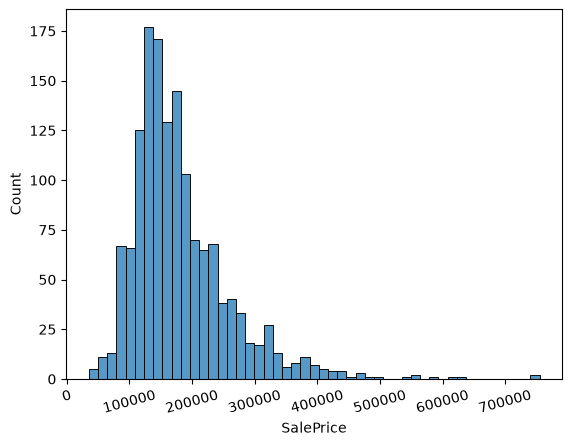

In [3]:
plt.xticks(rotation=15)
sns.histplot(df['SalePrice'])
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

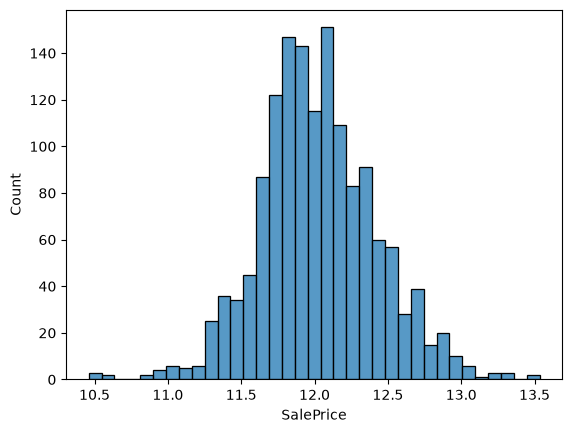

In [4]:
log_SalePrice = np.log1p(df['SalePrice'])
sns.histplot(log_SalePrice)

In [5]:
df['Id'].value_counts()

Id
1       1
2       1
3       1
4       1
5       1
       ..
1456    1
1457    1
1458    1
1459    1
1460    1
Name: count, Length: 1460, dtype: int64

In [6]:

X_test_dum = pd.get_dummies(df_test)

ids = df_test['Id']

In [7]:
# PoolQC          1453
# MiscFeature     1406
# Alley           1369
# Fence           1179
# MasVnrType       872
drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
df.drop(drop_cols, axis=1, inplace=True)

num_cols = df.dtypes[df.dtypes != 'str'].index
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [8]:
from sklearn.model_selection import train_test_split

y = df['SalePrice']
X = df.drop(['SalePrice'], axis=1)

In [9]:

print(X.shape)
print(y.shape)

(1460, 74)
(1460,)


In [10]:
X_dum = pd.get_dummies(X)

In [11]:
X_dum.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


In [12]:
X_train, X_val, y_train, y_val = train_test_split(X_dum, y,
                                                    test_size=0.3,
                                                    random_state=42)

In [13]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(n_estimators = 1000, learning_rate=0.05,
                   colsample_bytree=0.5, subsample=0.8)
lgbm = LGBMRegressor(n_estimators = 1000, learning_rate=0.05,
                   colsample_bytree=0.5, subsample=0.8, n_jobs=-1,
                   verbose=-1)
models = [xgb, lgbm]

xgb.fit(X_train, y_train)
xgb_val = xgb.predict(X_val)
xgb_mse = mean_squared_error(y_val, xgb_val)

lgbm.fit(X_train, y_train)
lgbm_val = lgbm.predict(X_val)
lgbm_mse = mean_squared_error(y_val, lgbm_val)

In [14]:
print(xgb_mse)
print(lgbm_mse)

532616960.0
696607452.5047841


In [15]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

xgb_reg = XGBRegressor(n_estimators = 1000, 
                       learning_rate=0.05, 
                       colsample_bytree=0.5,
                       subsample=0.8)

lgb_reg = LGBMRegressor(n_estimators=1000, 
                        learning_rate=0.05, 
                        colsample_bytree=0.5,
                        subsample=0.8, 
                        n_jobs=-1, 
                        verbose = -1)

xgb_reg.fit(X_train,y_train)
xgb_reg_val = xgb_reg.predict(X_val)
xgb_reg_mse = mean_squared_error(y_val, xgb_reg_val)

lgb_reg.fit(X_train, y_train)
lgb_reg_val = lgb_reg.predict(X_val)
lgb_reg_mse = mean_squared_error(y_val, lgb_reg_val)

In [16]:
print(xgb_reg_mse)
print(lgb_reg_mse)

532616960.0
696607452.5047841


In [17]:
test_df = pd.read_csv('../data/house_test.csv')
test_ids = test_df['Id']

test_df.drop(drop_cols, axis=1, inplace=True)

test_num_cols = test_df.dtypes[test_df.dtypes != 'str'].index
test_df[test_num_cols] = test_df[test_num_cols].fillna(df[test_num_cols].mean())

X_test_dum = pd.get_dummies(test_df)
X_test_dum = X_test_dum.reindex(columns=X_dum.columns, fill_value=0)

print(X_test_dum.shape)

(1459, 267)


In [18]:
pred_xgb = xgb.predict(X_test_dum)
pred_lgbm = lgbm.predict(X_test_dum)

res_xgb = pd.DataFrame({'Id': test_ids, 'SalePrice': pred_xgb})
res_lgbm = pd.DataFrame({'Id': test_ids, 'SalePrice': pred_lgbm})

In [19]:
res_xgb.to_csv('res_xgb.csv', index=False)
res_lgbm.to_csv('res_lgbm.csv', index=False)